In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget

from sklearn.metrics.cluster import adjusted_rand_score 
from itertools import combinations

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sc.settings.verbosity = 3
sc.logging.print_header()

08:59:06 - INFO - Old pandas version detected. Patching DataFrame.map to DataFrame.applymap
/nfs/turbo/umms-indikar/Cooper/conda_envs/scrapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/scrapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


Package,Version
ipykernel,6.29.5
pandas,2.0.3
numpy,1.26.4
matplotlib,3.10.1
seaborn,0.13.2
h5py,3.13.0
scipy,1.15.2
PyYAML,6.0.2
gget,0.29.0
scikit-learn,1.5.2


# Load the fibroblast data

In [2]:
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/cc_fibroblast_full/scfib/scfib.gene_raw_feature_bc_matrix/"

fib_adata = sc.read_10x_mtx(fpath)
fib_adata.obs['batch'] = 'fib'

print(f"Batch: Fibroblast")
print(f"\tTotal UMIs: {int(np.sum(fib_adata.X))}")
print(f"\tCells: {fib_adata.shape[0]}")
print(f"\tGenes: {fib_adata.shape[1]}")

--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Batch: Fibroblast
	Total UMIs: 106198152
	Cells: 8963
	Genes: 23635


# load and merge feature barcodes

In [3]:
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/cc_fibroblast_full/sc_fib_tsb_rerun/feature_barcodes/fbc_map.csv"
df = pd.read_csv(fpath)

# Sum columns for each condition:
df['G1'] = df.loc[:, df.columns.str.endswith('G1')].sum(axis=1)
df['S'] = df.loc[:, df.columns.str.endswith('S')].sum(axis=1)
df['G2M'] = df.loc[:, df.columns.str.endswith('G2M')].sum(axis=1)

# create a new dataframe with only the cell barcode and the summed conditions:
df = df[['cell_barcode', 'G1', 'S', 'G2M']]

df = df.groupby('cell_barcode', as_index=False).sum()
df['phase'] = df[['G1', 'S', 'G2M']].idxmax(axis=1)
df['cell_barcode'] = df['cell_barcode'] + "-1"
print(f"{df.shape=}")
barcode_map = dict(zip(df['cell_barcode'].values, df['phase'].values))
df.head()

df.shape=(10715, 5)


,cell_barcode,G1,S,G2M,phase
0,AAACCAAAGGGTAGCA-1,0.0,1.0,8.0,G2M
1,AAACCAAAGTAAGGGT-1,2.0,0.0,0.0,G1
2,AAACCATTCAGGTAGG-1,2.0,0.0,0.0,G1
3,AAACCATTCCAGCCCT-1,3.0,9.0,0.0,S
4,AAACCATTCGTGACCG-1,5.0,1.0,0.0,G1


In [4]:
fib_adata.obs['phase'] = fib_adata.obs.index.map(barcode_map)
print(fib_adata.obs['phase'].value_counts(dropna=False).to_string())

phase
G1     5733
S      1689
G2M    1453
NaN      88


# Load the reprogramming data

In [5]:
""" Loasd the HSC data """
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/hsc_epi2me_full/anndata/gene_adata.h5ad"
hsc_adata = sc.read_h5ad(fpath)
hsc_adata.obs['batch'] = 'hsc'
hsc_adata.obs['phase'] = 'unknown'

print(f"Batch: HSC")
print(f"\tTotal UMIs: {int(np.sum(hsc_adata.X))}")
print(f"\tCells: {hsc_adata.shape[0]}")
print(f"\tGenes: {hsc_adata.shape[1]}")

""" Combine """
adata = an.concat([hsc_adata, fib_adata])
sc.logging.print_memory_usage()
adata

Batch: HSC
	Total UMIs: 102131339
	Cells: 11403
	Genes: 25311
Memory usage: current 2.46 GB, difference +2.46 GB


AnnData object with n_obs × n_vars = 20366 × 22094
    obs: 'batch', 'phase'

In [6]:
""" Combine  data """
adata = an.concat([hsc_adata, fib_adata])
sc.logging.print_memory_usage()
adata

Memory usage: current 3.10 GB, difference +0.64 GB


AnnData object with n_obs × n_vars = 20366 × 22094
    obs: 'batch', 'phase'

In [7]:
# break

In [8]:
# Identify the overlapping genes between the two datasets
overlapping_genes = hsc_adata.var_names.intersection(fib_adata.var_names)

# Print overlapping genes information
print("############################################")
print("OVERLAPPING GENES INFORMATION")
print("############################################")
print(f"Total overlapping genes: {len(overlapping_genes)}")
print("First 10 overlapping genes:")
print(list(overlapping_genes[:10]))  # Convert to list for clearer display
print("############################################\n")

# Show the shape of the combined AnnData object before filtering
print("Shape of combined AnnData before gene filtering:", adata.shape)

# Filter the combined AnnData object to include only the overlapping genes.
# We use the correct slicing of cells (:) and genes (column indexer).
# print("Filtering AnnData to include only overlapping genes...")
# adata = adata[:, adata.var_names.isin(overlapping_genes)].copy()

# Print the shape of the AnnData object after filtering genes
print("Shape of combined AnnData after gene filtering:", adata.shape)

############################################
OVERLAPPING GENES INFORMATION
############################################
Total overlapping genes: 22094
First 10 overlapping genes:
['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A4GALT', 'A4GNT', 'AAAS', 'AACS']
############################################

Shape of combined AnnData before gene filtering: (20366, 22094)
Shape of combined AnnData after gene filtering: (20366, 22094)


In [9]:
aggdata = sc.get.aggregate(
    adata,
    by='batch',
    func='count_nonzero',
    axis=0,
)

df = pd.DataFrame(
    aggdata.layers['count_nonzero'].T.astype(int),
    columns=aggdata.obs['batch'].values,
    index=aggdata.var_names,
)

df.head()

df['filter_pass'] = (df['fib'] > 0) & (df['hsc'] > 0)

failed = df[~df['filter_pass']]
print(f"Number of failed genes {failed.shape[0]}")
failed = failed.sort_values(by='hsc', ascending=False)
failed.head()

Number of failed genes 0


,fib,hsc,filter_pass


# Filtering

In [10]:
adata.raw = adata  # keep full dimension safe

adata.layers['raw_counts'] = adata.X.copy()

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

rsc.get.anndata_to_CPU(adata)

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], 
    inplace=True, log1p=True
)

# rsc.get.anndata_to_GPU(adata)
sc.pp.filter_cells(adata, min_counts=500)
sc.pp.filter_genes(adata, min_counts=10)

min_n_genes = 1000
adata = adata[adata.obs['n_genes_by_counts'] > min_n_genes, :].copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.layers['log_norm'] = adata.X.copy()

rsc.get.anndata_to_GPU(adata) # move to GPU
adata

filtered out 3185 cells that have less than 500 counts
filtered out 682 genes that are detected in less than 10 counts
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts'
    uns: 'log1p'
    layers: 'raw_counts', 'log_norm'

In [11]:
adata.obs['batch'].value_counts()

batch
hsc    8326
fib    7541
Name: count, dtype: int64

# Aggregate Differences

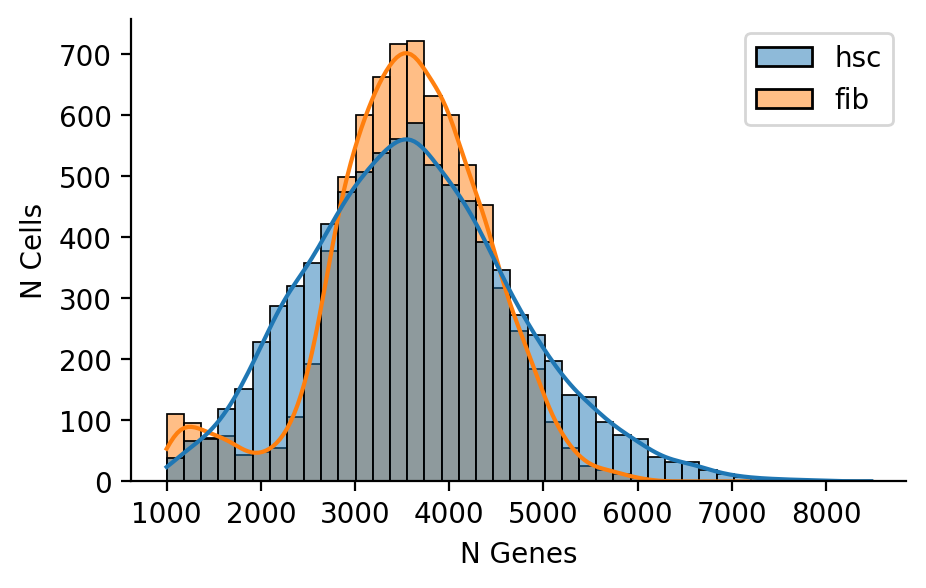

In [12]:
adata.obs['n_genes'] = adata.obs['n_genes_by_counts']

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3

sns.histplot(
    data=adata.obs,
    bins=41,
    x='n_genes',
    hue='batch',
    kde=True,
)

sns.move_legend(
    plt.gca(),
    title="",
    loc='best',
)
plt.ylabel('N Cells')
plt.xlabel('N Genes')

sns.despine()

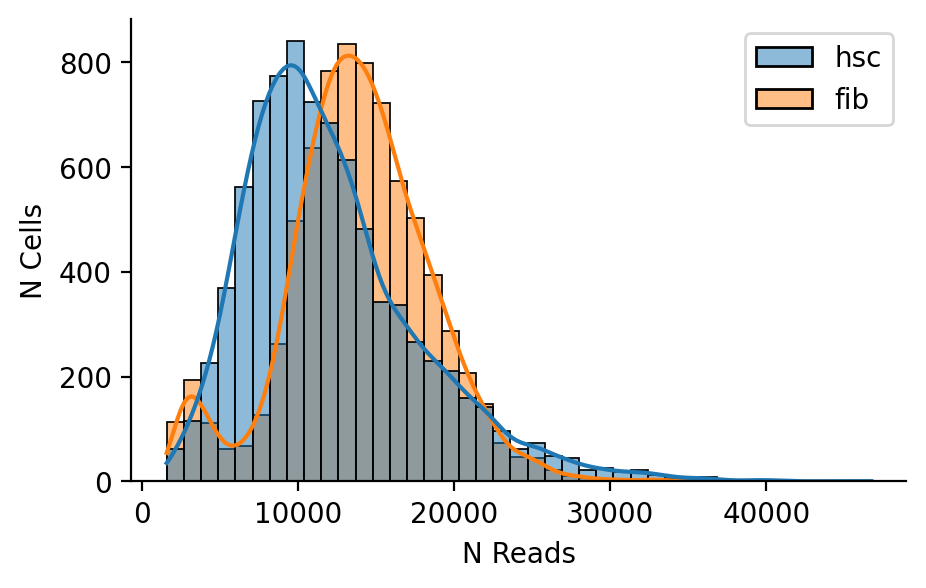

In [13]:
adata.obs['n_reads'] = adata.obs['total_counts']

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3

sns.histplot(
    data=adata.obs,
    bins=41,
    x='n_reads',
    hue='batch',
    kde=True,
)

sns.move_legend(
    plt.gca(),
    title="",
    loc='best',
)
plt.ylabel('N Cells')
plt.xlabel('N Reads')

sns.despine()

# Batch Effects

In [14]:
adata

AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts'
    uns: 'log1p'
    layers: 'raw_counts', 'log_norm'

In [15]:
# Using a t-test
sc.tl.rank_genes_groups(
    adata, 
    groupby='batch',
    method='t-test',
    layer='log_norm',
    use_raw=False,
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
)

deg.head()

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:03)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,fib,ISG15,252.343964,4.667170,0.0,0.0,0.988596,0.653495
1,fib,MX1,231.172302,6.184198,0.0,0.0,0.971754,0.078789
2,fib,MT-ATP8,229.850342,5.248065,0.0,0.0,0.984750,0.516695
3,fib,IFIT3,204.111771,4.854284,0.0,0.0,0.968439,0.221835
4,fib,IFI16,193.928772,4.118933,0.0,0.0,0.973478,0.321643


Setting parameters...
Selected group: hsc
Using p-value cutoff: 0.05 and log fold change cutoff: 1.0
Subsetting the deg dataframe for the selected group...
Data subset complete. DataFrame shape: (21412, 8)
Calculating negative log10-transformed p-values...
Added column 'neg_log10_pvals'.
Flagging significant genes based on p-value and log fold change thresholds...
Added column 'significant'. Here are the counts for significant vs non-significant genes:
significant
False    12340
True      9072
Name: count, dtype: int64
Setting Seaborn style for plotting...
Creating the volcano plot figure...
Plotting scatterplot...
Adding cutoff lines for log fold change and p-value...
Labeling axes and setting the title...
Adjusting the legend...
Displaying the plot...


/home/cstansbu/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


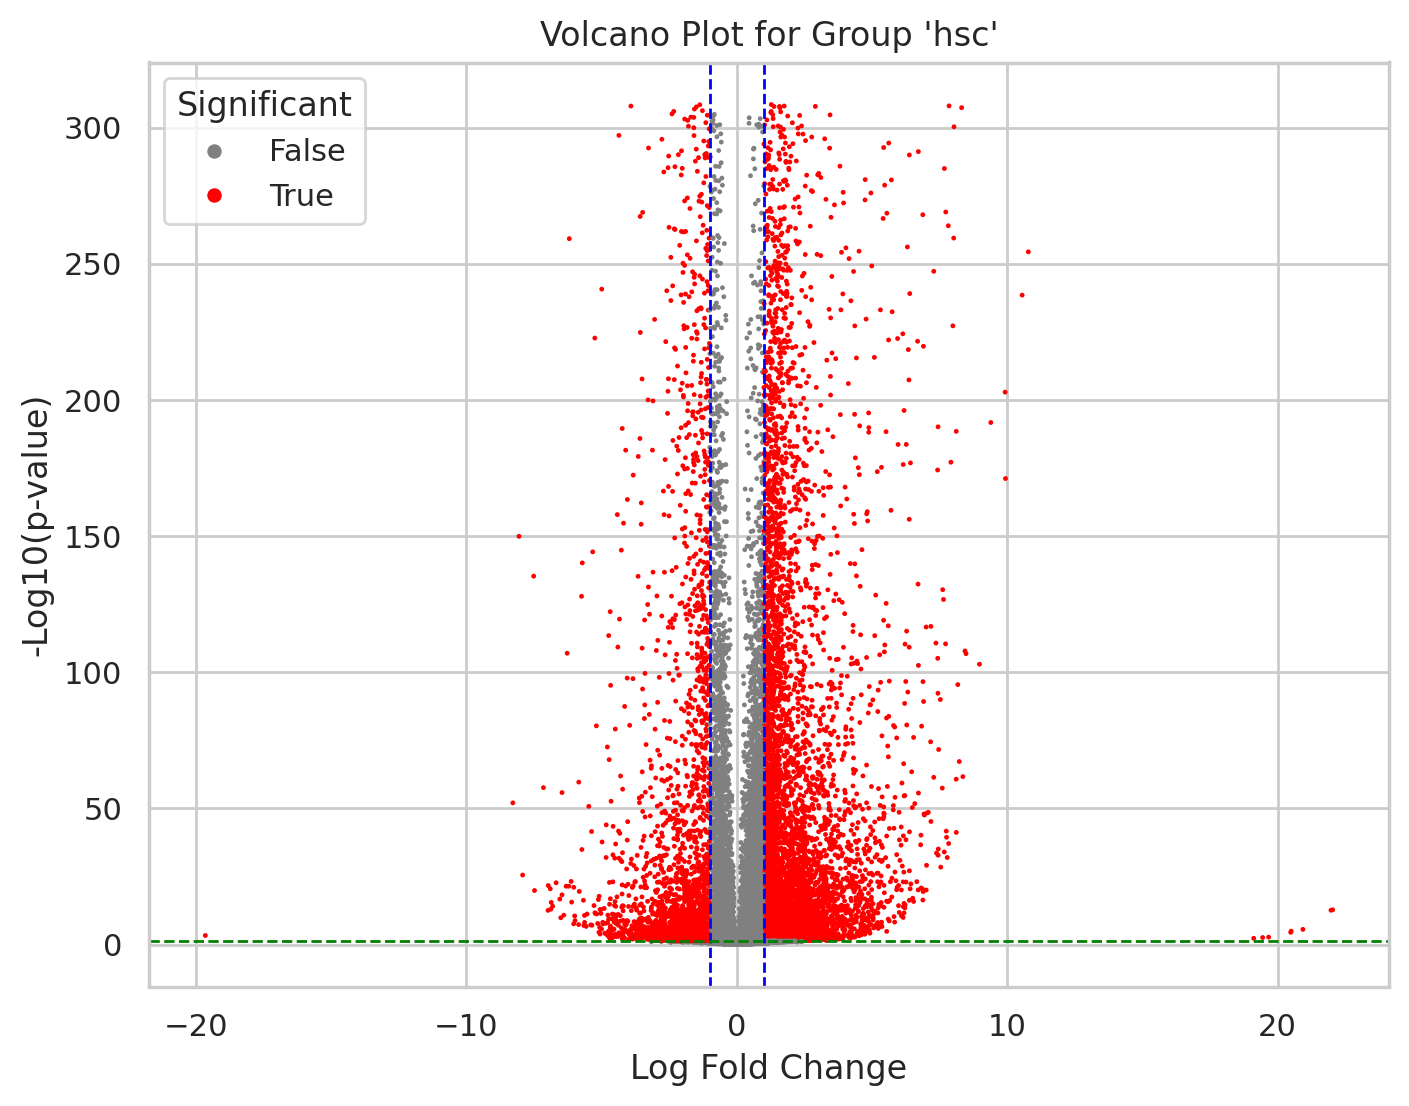

In [16]:
# --- Parameters ---
print("Setting parameters...")
# Choose the group (batch) you want to visualize, e.g., 'batch1'
group = 'hsc'  # replace with your actual group name
print(f"Selected group: {group}")

# Significance cutoffs: adjust these thresholds as needed
pval_cutoff = 0.05       # p-value threshold
logfc_cutoff = 1.0       # log fold change threshold
print(f"Using p-value cutoff: {pval_cutoff} and log fold change cutoff: {logfc_cutoff}")

# --- Data Preparation ---
print("Subsetting the deg dataframe for the selected group...")
df = deg[deg['group'] == group].copy()
print(f"Data subset complete. DataFrame shape: {df.shape}")

# Create a new column for the negative log10-transformed p-values,
# which is used for the y-axis of the volcano plot.
print("Calculating negative log10-transformed p-values...")
df['neg_log10_pvals'] = -np.log10(df['pvals_adj'])
print("Added column 'neg_log10_pvals'.")

# Optional: Define a new column to flag "significant" genes based on your criteria.
print("Flagging significant genes based on p-value and log fold change thresholds...")
df['significant'] = (df['pvals_adj'] < pval_cutoff) & (abs(df['logfoldchanges']) >= logfc_cutoff)
print("Added column 'significant'. Here are the counts for significant vs non-significant genes:")
print(df['significant'].value_counts())

# --- Plotting ---
print("Setting Seaborn style for plotting...")
sns.set(style="whitegrid")

print("Creating the volcano plot figure...")
plt.figure(figsize=(8, 6))

print("Plotting scatterplot...")
scatter_plot = sns.scatterplot(
    data=df,
    x='logfoldchanges',
    y='neg_log10_pvals',
    hue='significant',
    palette={True: 'red', False: 'grey'},
    edgecolor="none",
    s=3,
)

print("Adding cutoff lines for log fold change and p-value...")
plt.axvline(x=logfc_cutoff, color='blue', linestyle='--', linewidth=1)
plt.axvline(x=-logfc_cutoff, color='blue', linestyle='--', linewidth=1)
plt.axhline(y=-np.log10(pval_cutoff), color='green', linestyle='--', linewidth=1)

print("Labeling axes and setting the title...")
plt.xlabel("Log Fold Change")
plt.ylabel("-Log10(p-value)")
plt.title(f"Volcano Plot for Group '{group}'")

print("Adjusting the legend...")
plt.legend(title="Significant", loc="upper left", markerscale=3)

print("Displaying the plot...")
plt.show()


# Feature Selection

Number of genes before HVG selection: 21412
Number of HVG: 2813


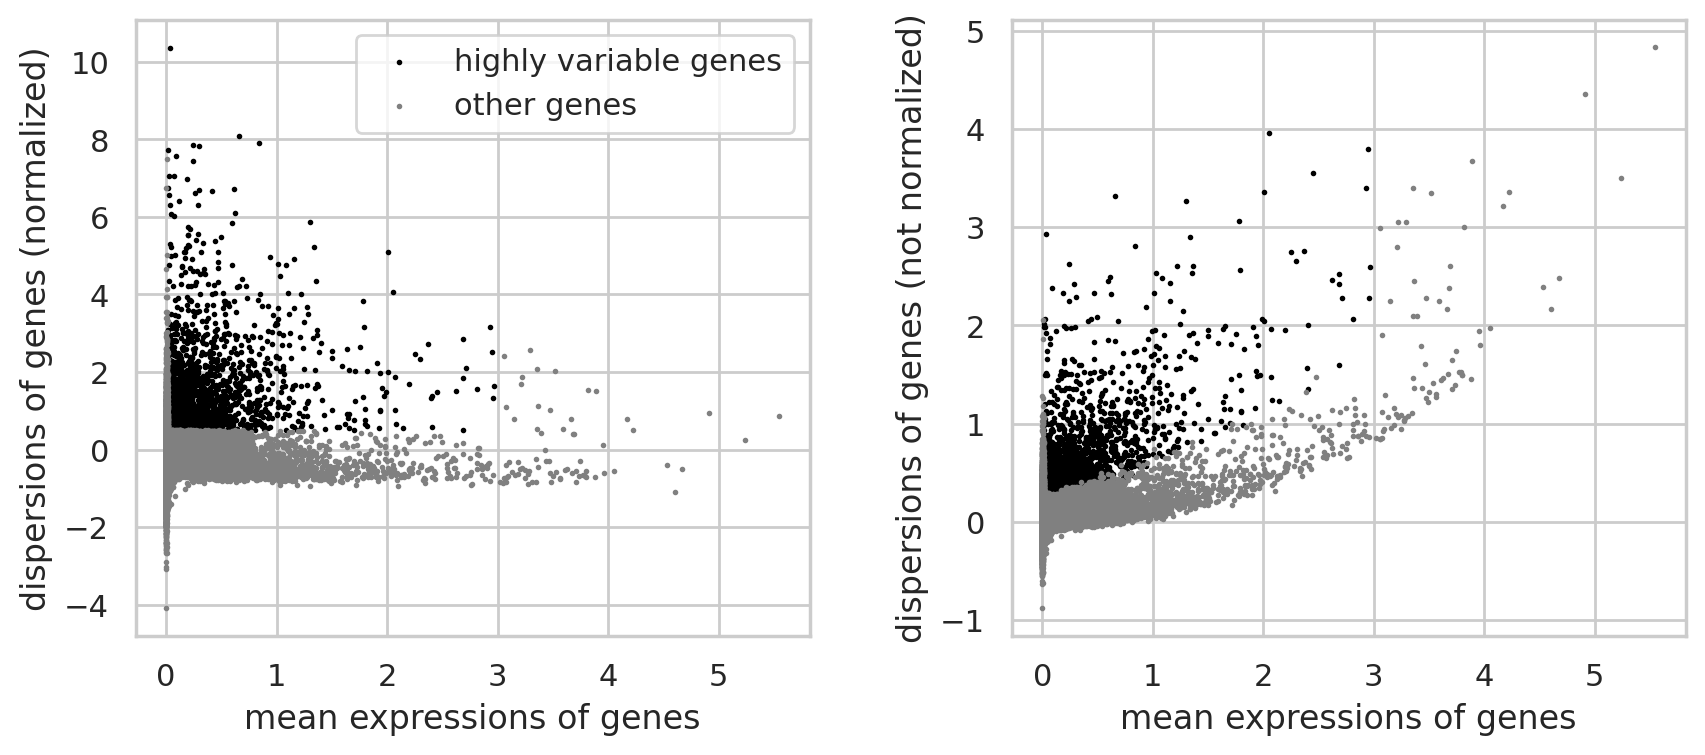

AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'rank_genes_groups', 'hvg'
    layers: 'raw_counts', 'log_norm'

In [17]:
print(f"Number of genes before HVG selection: {adata.n_vars}")

rsc.pp.highly_variable_genes(
    adata, 
    batch_key='batch',
)

print(f"Number of HVG: {adata.var['highly_variable'].sum()}")

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 4
sc.pl.highly_variable_genes(
    adata
)

adata

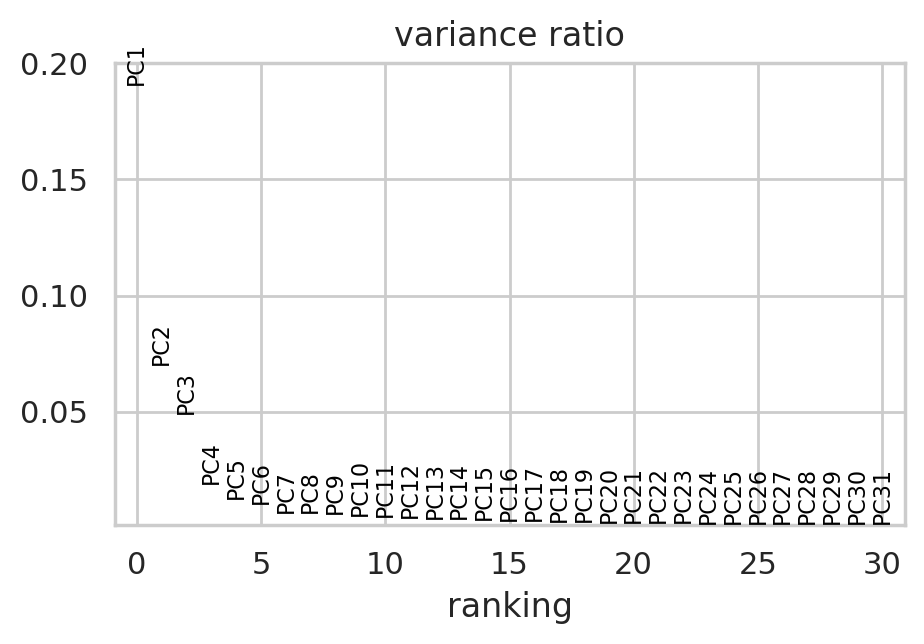

AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'rank_genes_groups', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'raw_counts', 'log_norm'

In [18]:
rsc.pp.pca(
    adata,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3
sc.pl.pca_variance_ratio(
    adata
)

adata

[2025-04-16 09:00:09.986] [CUML] [debug] n_neighbors=15
[2025-04-16 09:00:09.986] [CUML] [debug] Calling knn graph run
[2025-04-16 09:00:09.986] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-04-16 09:00:10.139] [CUML] [debug] Done. Calling remove zeros


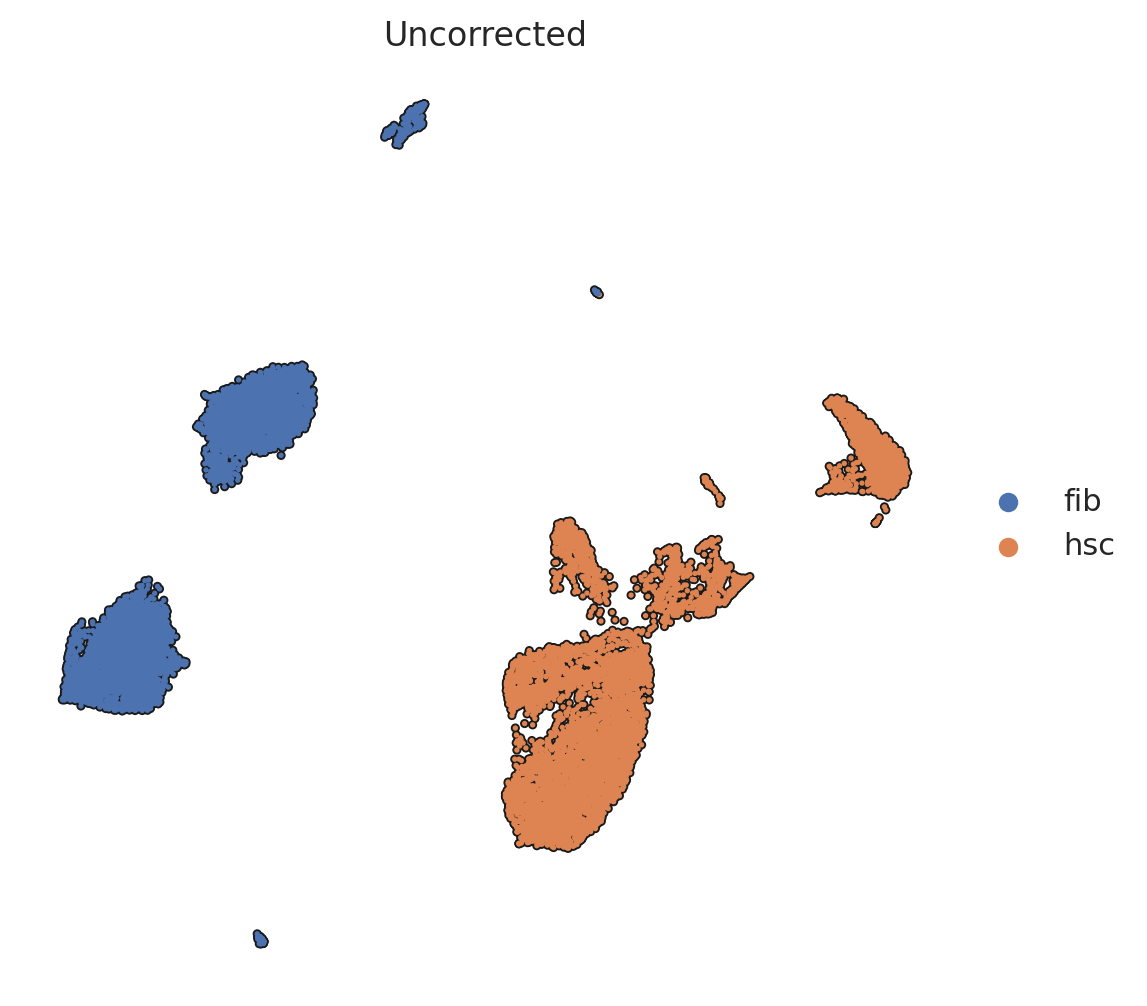

In [19]:
rsc.pp.neighbors(
    adata,
)

rsc.tl.umap(
    adata,
    min_dist=0.2,
)

adata.obsm['X_umap_raw'] = adata.obsm['X_umap'].copy()

rsc.tl.leiden(adata, resolution=0.2, key_added='raw_clusters')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 6

sc.pl.umap(
    adata,
    ncols=1,
    color=['batch'],
    size=15,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
    title='Uncorrected',
)


# Simple batch correction

[2025-04-16 09:00:12.710] [RAFT] [info] optimizing graph
[2025-04-16 09:00:12.724] [RAFT] [info] Graph optimized, creating index
[2025-04-16 09:00:13.325] [RAFT] [info] optimizing graph
[2025-04-16 09:00:13.341] [RAFT] [info] Graph optimized, creating index


[2025-04-16 09:00:13.351] [CUML] [debug] n_neighbors=6
[2025-04-16 09:00:13.351] [CUML] [debug] Calling knn graph run
[2025-04-16 09:00:13.352] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-04-16 09:00:13.352] [CUML] [debug] Done. Calling remove zeros


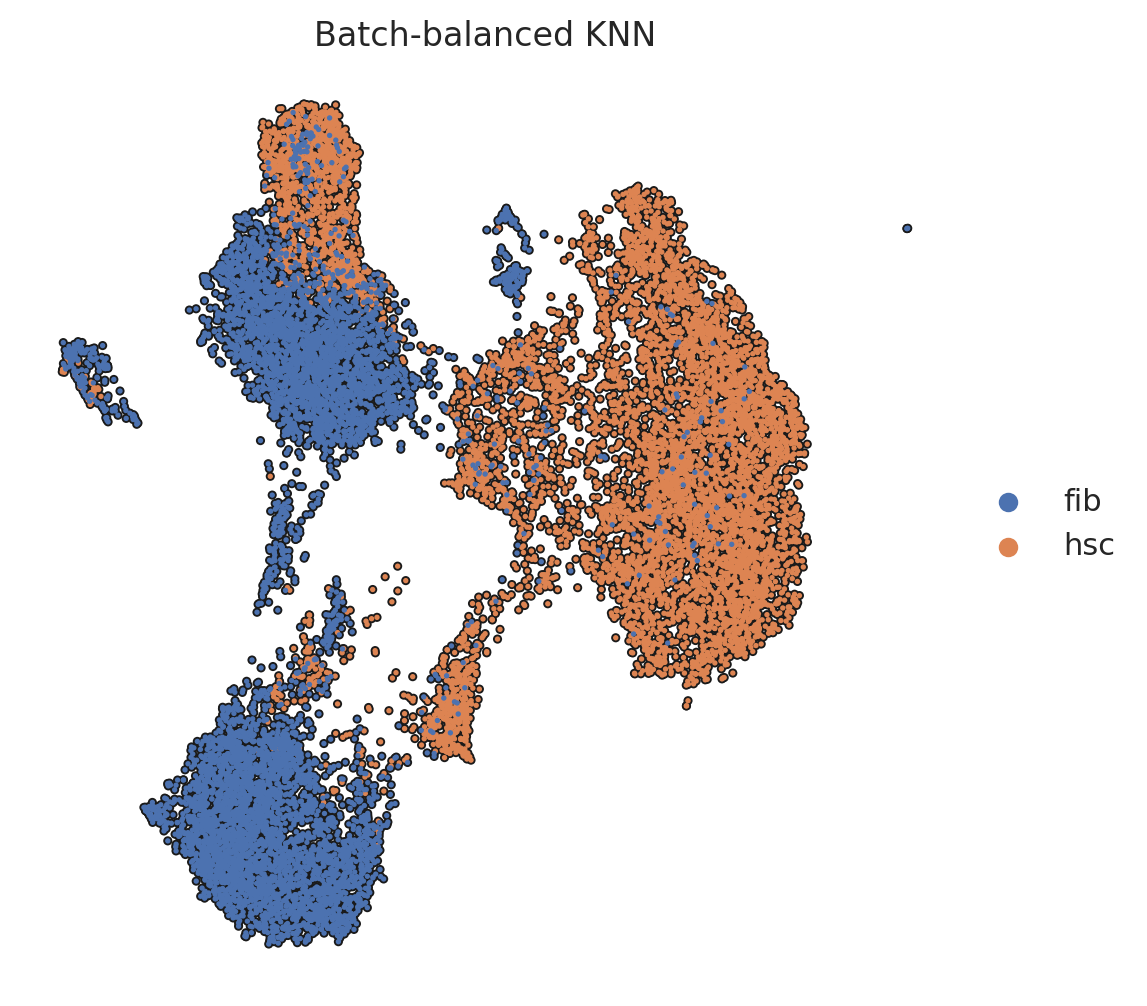

In [20]:
rsc.pp.bbknn(
    adata,
    batch_key='batch',
    use_rep='X_pca',
    # neighbors_within_batch=15,
    trim=8,
    algorithm='cagra',
)

rsc.tl.leiden(adata, resolution=0.2, key_added='bbknn_clusters')

rsc.tl.umap(
    adata,
    min_dist=0.2,
)

adata.obsm['X_umap_bbknn'] = adata.obsm['X_umap'].copy()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 6

sc.pl.umap(
    adata,
    ncols=1,
    color=['batch',],   
    size=15,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
    title="Batch-balanced KNN"
)

[2025-04-16 09:00:20.996] [CUML] [debug] n_neighbors=15
[2025-04-16 09:00:20.996] [CUML] [debug] Calling knn graph run
[2025-04-16 09:00:20.996] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-04-16 09:00:20.998] [CUML] [debug] Done. Calling remove zeros


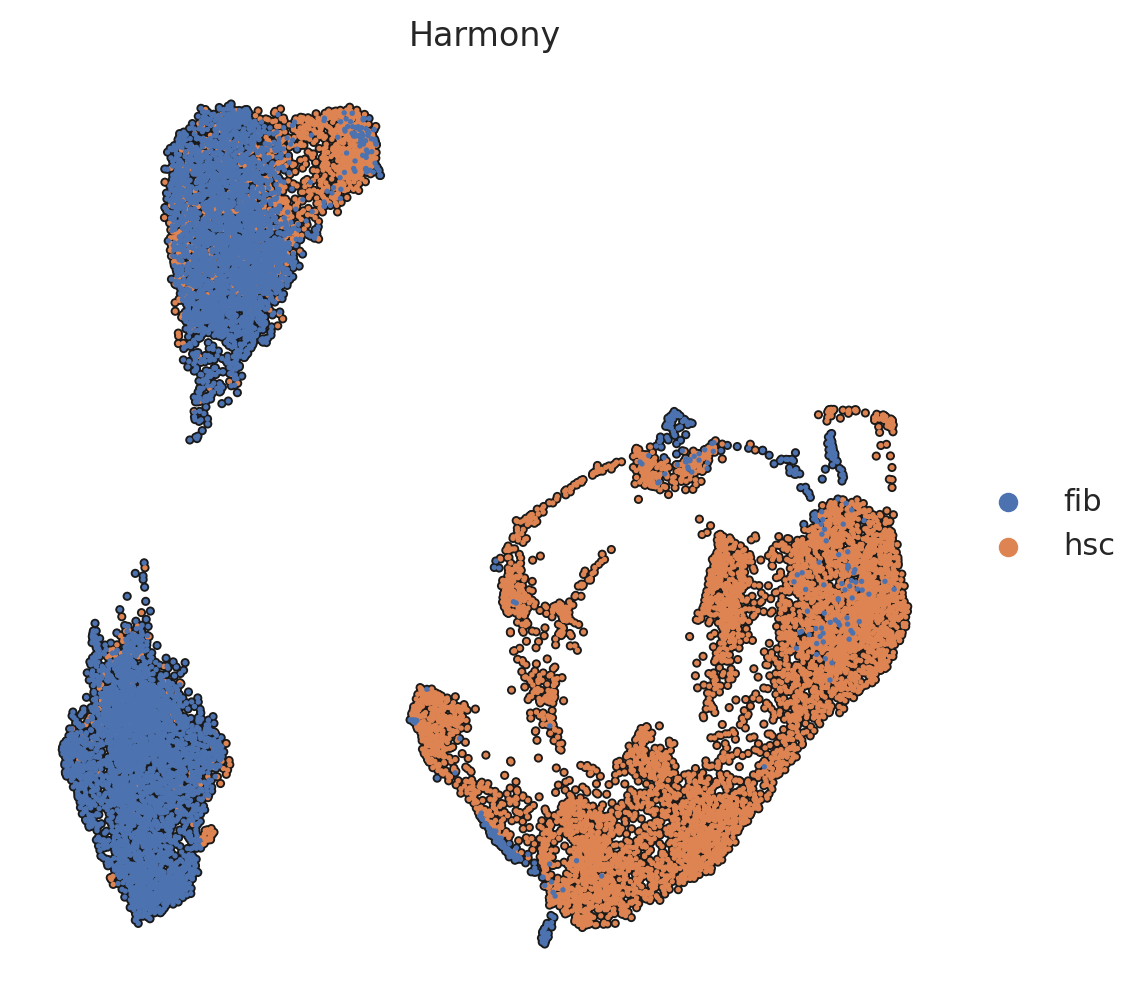

In [21]:
rsc.pp.harmony_integrate(
    adata, 
    'batch',
)

rsc.pp.neighbors(
    adata,
    use_rep='X_pca_harmony',
    
)

rsc.tl.leiden(adata, resolution=0.2, key_added='harmony_clusters')
adata.obs['cluster_str'] = adata.obs['harmony_clusters'].astype(int).apply(lambda x: f"C{x+1}")

rsc.tl.umap(
    adata,
    min_dist=0.2,
)

adata.obsm['X_umap_harmony'] = adata.obsm['X_umap'].copy()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 6

sc.pl.umap(
    adata,
    ncols=1,
    color=['batch',],   
    size=15,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
    title="Harmony"
)

# cluster overlap

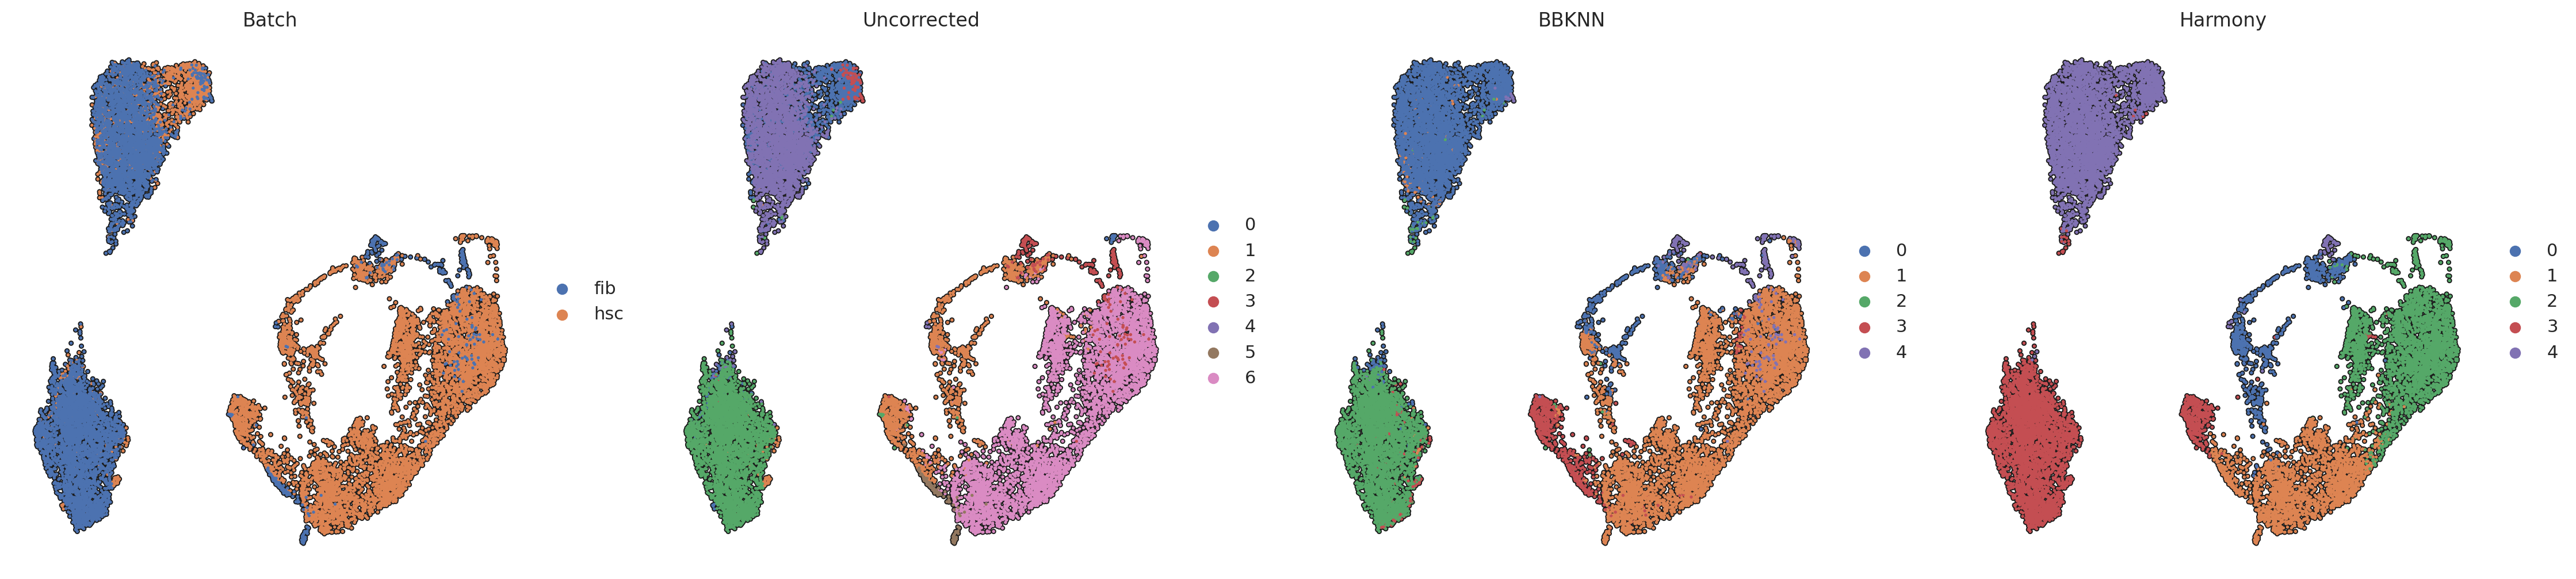

In [22]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 6

sc.pl.umap(
    adata,
    ncols=4,
    color=['batch', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters'],
     size=15,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
    title=['Batch', "Uncorrected", "BBKNN", "Harmony"]
)

In [25]:
# 1. Identify label columns
label_cols = ['raw_clusters', 'bbknn_clusters', 'harmony_clusters'] 

# 2. Calculate Pairwise Scores (using ARI here)
pairwise_scores = {}
all_scores = []

print("Calculating pairwise similarities (using Adjusted Rand Index):")

for col1, col2 in combinations(label_cols, 2):
    score = adjusted_rand_score(adata.obs[col1], adata.obs[col2])
    pairwise_scores[f'{col1}_vs_{col2}'] = score
    all_scores.append(score)
    print(f"- ARI between '{col1}' and '{col2}': {score:.4f}")

# 3. (Optional) Create a matrix view (more visual for many label sets)
num_labels = len(label_cols)
score_matrix = pd.DataFrame(np.ones((num_labels, num_labels)), index=label_cols, columns=label_cols)

for i in range(num_labels):
    for j in range(i + 1, num_labels):
        col1 = label_cols[i]
        col2 = label_cols[j]
        # Use adjusted_rand_score or retrieve from pairwise_scores if already calculated
        score = adjusted_rand_score(adata.obs[col1], adata.obs[col2])
        score_matrix.loc[col1, col2] = score
        score_matrix.loc[col2, col1] = score # Matrix is symmetric

print("\nPairwise ARI Matrix:")
print(score_matrix.round(4).to_latex())


# 4. (Optional) Calculate Average Score
if all_scores:
    average_score = np.mean(all_scores)
    print(f"\nAverage Pairwise ARI across all pairs: {average_score:.4f}")
else:
    print("\nNot enough label sets to calculate pairwise scores.")


Calculating pairwise similarities (using Adjusted Rand Index):
- ARI between 'raw_clusters' and 'bbknn_clusters': 0.7384
- ARI between 'raw_clusters' and 'harmony_clusters': 0.6242
- ARI between 'bbknn_clusters' and 'harmony_clusters': 0.6515

Pairwise ARI Matrix:
\begin{tabular}{lrrr}
\toprule
 & raw_clusters & bbknn_clusters & harmony_clusters \\
\midrule
raw_clusters & 1.000000 & 0.738400 & 0.624200 \\
bbknn_clusters & 0.738400 & 1.000000 & 0.651500 \\
harmony_clusters & 0.624200 & 0.651500 & 1.000000 \\
\bottomrule
\end{tabular}


Average Pairwise ARI across all pairs: 0.6714


# Write to File

In [26]:
outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/processed.h5ad"
adata.write(outpath)
adata

AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'rank_genes_groups', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'batch_colors', 'raw_clusters_colors', 'bbknn_clusters_

In [ ]:
break

# Archive

# Harmony Analysis

In [ ]:
# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['figure.figsize'] = 6, 6

# for column in ['cluster_str', 'batch']:

#     sc.pl.umap(
#         adata,
#         ncols=1,
#         color=column,   
#         size=15,
#         add_outline=True,
#         outline_color=('k', 'k'),
#         alpha=1,
#         frameon=False,
#         title="",
#     )

In [ ]:
# Create a frequency table of 'batch' and 'cluster_str'
df = adata.obs[['batch', 'cluster_str']].value_counts().reset_index(name='count')

# Calculate percentage within each batch (dataset)
df['percentage'] = df.groupby('batch')['count'].transform(lambda x: 100 * x / x.sum())

# Optionally, round the percentage to one decimal place
df['percentage'] = df['percentage'].round(1)

# Sort by dataset ('batch') and then by count (descending order)
df = df.sort_values(by=['batch', 'cluster_str'], ascending=[True, True])

# Print the table without the default DataFrame index
print(df.to_latex(index=False))

In [ ]:
break

# Write to file

In [ ]:
outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/processed.h5ad"
# adata.write(outpath)
# adata

# Quick Visualization

In [ ]:
query = [
    'CD34', 'REL', 'GATA2', 'STAT5A', 'FOS', 'DCN'
]

sc.pl.umap(
    adata,
    ncols=3,
    color=query,   
    size=25,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    cmap='viridis',
    layer='log_norm',
    frameon=False,
)


# DEG on Clusters C2 + C3

In [ ]:
adata.obs['group'] = np.where(adata.obs['cluster_str'].isin(['C2', 'C3']), 'reprogramming', 'control')

sc.tl.rank_genes_groups(
    adata, 
    groupby='group',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group='reprogramming',
    
    pval_cutoff=0.01,
)

deg.head()

In [ ]:
deg.tail()

# DEG on Clusters

In [ ]:
sc.tl.rank_genes_groups(
    adata, 
    groupby='cluster_str',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    pval_cutoff=0.01,
)

deg.head()

In [ ]:
sig = deg[deg['group'].isin(['C2', 'C3'])]
sig = sig[sig['logfoldchanges'] > 1.5]
print(f"{sig.shape=}")

database = 'ontology'
# database = 'celltypes'

edf = gget.enrichr(sig['names'].to_list(), database=database)

print(edf[['path_name', 'adj_p_val', 'overlapping_genes']].head(10).to_string(index=False))

In [ ]:
break

In [ ]:
query = [
   "CD34",     
    "ACE",       
     "RUNX1",     # RUNX family transcription factor 1 (AML1) - Essential for definitive hematopoiesis establishment and HSC function.
    "GATA2",     # GATA binding protein 2 - Critical for HSC survival, maintenance, and proliferation.
    "TAL1",      # TAL bHLH transcription factor 1 (SCL) - Master regulator in hematopoietic development.
    "LMO2",      # LIM domain only 2 - Forms complexes with TAL1, GATA factors.
    "MYB",       # MYB proto-oncogene, transcription factor - Regulates proliferation/differentiation balance.
    "ERG",       # ETS transcription factor ERG - Important for HSC maintenance and quiescence.
    "FLI1",      # Fli-1 proto-oncogene, ETS transcription factor - Involved in megakaryopoiesis and HSC function.
    "GFI1",      # Growth factor independent 1 transcription repressor - Regulates HSC self-renewal and lineage commitment.
    "GFI1B",     # Growth factor independent 1B transcription repressor - Works with GFI1, important for erythroid/megakaryocytic paths.
    "IKZF1",     # IKAROS family zinc finger 1 (Ikaros) - Crucial for lymphoid development, also impacts HSCs.
    "IKZF2",     # IKAROS family zinc finger 2 (Helios) - Related to Ikaros, involved in HSC/progenitor function.
    "SPI1",      # Spi-1 proto-oncogene (PU.1) - Master regulator of myeloid development, expressed at HSC/MPP stage.
    "CEBPA",     # CCAAT enhancer binding protein alpha - Key for granulopoiesis, important at GMP stage, influences HSCs.

    # --- Regulators of Self-Renewal, Quiescence, and Proliferation ---
    "MEIS1",     # Meis homeobox 1 - Cooperates with HOX genes, promotes self-renewal/inhibits differentiation.
    "PBX1",      # PBX homeobox 1 - Co-factor for HOX and MEIS proteins.
    "HOXA9",     # Homeobox A9 - Promotes HSC expansion and self-renewal.
    "HOXB4",     # Homeobox B4 - Promotes HSC expansion.
    "STAT3",     # Signal transducer and activator of transcription 3 - Mediates cytokine signaling (e.g., IL-6, G-CSF).
    "STAT5A",    # Signal transducer and activator of transcription 5A - Mediates cytokine signaling (e.g., TPO, IL-3, SCF).
    "STAT5B",    # Signal transducer and activator of transcription 5B - Works closely with STAT5A.
    "FOXO3",     # Forkhead box O3 - Promotes quiescence and stress resistance.
    "EGR1",      # Early growth response 1 - Involved in regulating quiescence/activation cycles.
    "HIF1A",     # Hypoxia inducible factor 1 subunit alpha - Key regulator in response to low oxygen in the niche.
    "BMI1",      # BMI1 proto-oncogene, polycomb ring finger - Polycomb complex member, essential for long-term self-renewal.
    "ZFP36L2",   # ZFP36 ring finger protein like 2 - RNA-binding protein acting like a TF regulator, promotes quiescence.
    "KLF4",      # KLF transcription factor 4 - Involved in maintaining HSC function.
    "NR4A1"

]

query = [x for x in query if x in adata.var_names]


sc.pl.umap(
    adata,
    ncols=3,
    color=query,   
    size=25,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    cmap='viridis',
    layer='log_norm',
    frameon=False,
)


In [ ]:
query = [
    "MAGI1", "PECAM1", "NDRG4", "NYAP1", "CMTM4", "KCNIP3", "SHROOM2", "AGAP1", "HSPA12A", "EGFR", "GPRC5B", "ZNRF3", "FMNL2", "PSD3", "SH3PXD2B", "MPDZ", "NGEF",
]

sc.pl.umap(
    adata,
    ncols=3,
    color=query,   
    size=25,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    cmap='viridis',
    layer='log_norm',
    frameon=False,
)


In [ ]:
break

# scVI

In [ ]:
scvi.model.SCVI.setup_anndata(
    adata, 
    layer="raw_counts",
    batch_key="batch",
)

model = scvi.model.SCVI(
    adata,
    n_layers=2,
    n_latent=24,
    gene_likelihood="nb",
)

model.train(
    max_epochs=100,
    accelerator="gpu",
    devices="auto",
    enable_model_summary=True,
    batch_size=1000,
    early_stopping=True,
    early_stopping_patience=2,
    early_stopping_monitor='validation_loss',
)

adata.obsm["X_scVI"] = model.get_latent_representation()
adata.layers["scvi_normalized"] = model.get_normalized_expression(library_size=10e4)
print(f"{adata.obsm["X_scVI"].shape=}")

In [ ]:
rsc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=15)
rsc.tl.leiden(adata, resolution=0.2)

rsc.tl.umap(adata, min_dist=0.25)

sc.pl.umap(
    adata,
    color=['batch', 'leiden',],
    frameon=False,
    ncols=1,
)

In [ ]:
break

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 1.5, 3

sns.boxplot(
    data=adata.obs,
    x='batch',
    hue='batch',
    y='n_reads',
    linecolor='k',
)

plt.xlabel('')
plt.ylabel('N Reads')

sns.despine()

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 1.5, 3

sns.boxplot(
    data=adata.obs,
    x='batch',
    hue='batch',
    y='n_genes',
    linecolor='k',
)

plt.xlabel('')
plt.ylabel('N Genes')

sns.despine()

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5

sns.scatterplot(
    data=adata.obs,
    x='n_reads',
    y='n_genes',
    hue='batch',
    ec='none',
    s=2,
    alpha=0.5,
)

sns.move_legend(
    plt.gca(),
    title="",
    loc='best',
    markerscale=2,
)
plt.ylabel('N Genes')
plt.xlabel('N Reads')

sns.despine()

# Genes in only one condition

In [ ]:
aggfunc = 'count_nonzero'

aggdata = sc.get.aggregate(
    adata,
    by='batch',
    func=aggfunc,
    axis='obs'
)

df = aggdata.to_df(layer=aggfunc).T
df = df.reset_index(names='gene_id')
df['gene_name'] = df['gene_id'].map(gene_map)
df.head()

In [ ]:
df[['control', 'hybrid']].corr()

In [ ]:
df['diff'] = df['hybrid'] - df['control']
df['diff_abs'] = df['diff'].abs()

df.sort_values(by='diff_abs', ascending=False).head(25)

In [ ]:
# filter out MT and RP genes
print(f"Raw: {df.shape=}")
df = df[df['diff_abs'] < adata.shape[0] * 0.1]
print(f"Filtered: {df.shape=}")

df[['control', 'hybrid']].corr()

In [ ]:
# break

In [ ]:
# ?sc.pp.highly_variable_genes

In [ ]:
sc.pp.highly_variable_genes(
    adata,
    flavor='seurat_v3',
    # n_top_genes=1500,
    
)

sc.pp.pca(
    adata,
)

sc.pl.pca_variance_ratio(adata)

In [ ]:
adata

In [ ]:
sc.pp.neighbors(
    adata,
)

sc.tl.umap(
    adata
)

sc.pl.umap(
    adata,
    color=['batch', 'n_genes', 'n_reads'],
    ncols=1,
)

In [ ]:
break

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5

sns.scatterplot(
    data=df,
    x='control',
    y='hybrid',
    s=2,
    ec='none',
)

# plt.yscale('log')
# plt.xscale('log')

In [ ]:
type(adata.X)

In [ ]:
adata.to_df().head()